Project Video Link:
https://youtu.be/Ipt4URoLhiE

#Executive Summary

Using the OSMI Mental Health in Tech survey, we built supervised classification models to predict whether a respondent had sought mental health treatment. The strongest model was Spark Random Forest, achieving about 84.6%% accuracy, 80.2%% recall, and 0.847 ROC-AUC on the test set. The most important predictors were work interference, family history, care options, age group, and perceived mental-health consequences. Business-wise, the model is most useful not as a diagnosis tool, but as a screening and prioritization tool for organizations deciding where to improve benefits visibility, manager training, and low-friction support access.

#Problem Domain

Mental health support is a workplace issue, especially in tech environments where employees may experience stress, stigma, and uncertainty about available resources. For organizations, the challenge is not only whether support exists, but whether employees who may benefit from support actually recognize, trust and use it. This project asks whether workplace survey responses can help identify patterns associated with treatment-seeking and reveal where organizational interventions may reduce hidden unmet need.


#ML Task at Hand

Task: Predicting whether a respondent is currently receiving mental-health


Experience: Historical survey responses from tech workers


Performance: Accuracy(Most Important), F1(the balance between precision, recall) and ROC-AUC


Value: Identify groups likely to need support but not currently receiving treatment


#Dataset

The dataset contains 1259 survey responses and 27 original columns from the OSMI Mental Health in Tech survey. After removing invalid ages and dropping timestamp/comments, the cleaned dataset contained 1,254 records. Our target variable is treatment, coded as whether the respondent reported receiving mental-health treatment. The target was nearly balanced: 50.5% Yes and 49.5% No. Key columns within this dataset included Age, Gender, family_history, work_interfere, benefits, care_options, wellness_program, seek_help, anonymity, leave, etc.


# Data Cleaning

We removed Timestamp because it does not provide meaningful predictive value for this task. We removed comments because they are mostly missing and unstructured. We filtered invalid ages outside a plausible human range and designated buckets for each age group. Gender responses were normalized into Male, Female, and Other because the raw survey included many free-text variants. Missing categorical values were treated as Unknown rather than dropped, because uncertainty itself may be meaningful in workplace survey data.

A key assumption is that survey responses are self-reported and may reflect perception, stigma, or recall bias. The model predicts reported treatment-seeking behavior, not clinical mental-health status.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Load data
df = pl.read_csv(path + "/survey.csv")

# Drop irrelevant columns
df = df.drop(["Timestamp", "comments"])

# Clean age
df = df.filter((pl.col("Age") > 0) & (pl.col("Age") < 100))

# Clean gender
df = df.with_columns(
    pl.col("Gender")
    .cast(pl.Utf8)
    .str.to_lowercase()
    .str.strip_chars()
    .alias("Gender")
)

df = df.with_columns(
    pl.when(pl.col("Gender").is_in([
        "male", "m", "man", "cis male", "male-ish", "maile",
        "mal", "msle", "mail", "make"
    ]))
    .then(pl.lit("Male"))
    .when(pl.col("Gender").is_in([
        "female", "f", "woman", "cis female", "femake"
    ]))
    .then(pl.lit("Female"))
    .otherwise(pl.lit("Other"))
    .alias("Gender_clean")
)

# Fill missing values
df = df.fill_null("Unknown")

# Create age buckets
df = df.with_columns(
    pl.when(pl.col("Age") < 25).then(pl.lit("18-24"))
    .when((pl.col("Age") >= 25) & (pl.col("Age") < 35)).then(pl.lit("25-34"))
    .when((pl.col("Age") >= 35) & (pl.col("Age") < 45)).then(pl.lit("35-44"))
    .when((pl.col("Age") >= 45) & (pl.col("Age") < 55)).then(pl.lit("45-54"))
    .when((pl.col("Age") >= 55) & (pl.col("Age") < 65)).then(pl.lit("55-64"))
    .otherwise(pl.lit("65+"))
    .alias("Age_bucket")
)

# Create binary target
df = df.with_columns(
    pl.when(pl.col("treatment") == "Yes")
    .then(1)
    .otherwise(0)
    .alias("target")
)

print(df.shape)
print(df.head())

Using Colab cache for faster access to the 'mental-health-in-tech-survey' dataset.
(1254, 28)
shape: (5, 28)
┌─────┬────────┬────────────────┬───────┬───┬─────────────────┬──────────────┬────────────┬────────┐
│ Age ┆ Gender ┆ Country        ┆ state ┆ … ┆ obs_consequence ┆ Gender_clean ┆ Age_bucket ┆ target │
│ --- ┆ ---    ┆ ---            ┆ ---   ┆   ┆ ---             ┆ ---          ┆ ---        ┆ ---    │
│ i64 ┆ str    ┆ str            ┆ str   ┆   ┆ str             ┆ str          ┆ str        ┆ i32    │
╞═════╪════════╪════════════════╪═══════╪═══╪═════════════════╪══════════════╪════════════╪════════╡
│ 37  ┆ female ┆ United States  ┆ IL    ┆ … ┆ No              ┆ Female       ┆ 35-44      ┆ 1      │
│ 44  ┆ m      ┆ United States  ┆ IN    ┆ … ┆ No              ┆ Male         ┆ 35-44      ┆ 0      │
│ 32  ┆ male   ┆ Canada         ┆ NA    ┆ … ┆ No              ┆ Male         ┆ 25-34      ┆ 0      │
│ 31  ┆ male   ┆ United Kingdom ┆ NA    ┆ … ┆ Yes             ┆ Male         ┆ 25-3

#Data Analysis

In [ ]:
# Goal: Find useful variables for predicting treatment
features_to_check = [
    "work_interfere",
    "family_history",
    "care_options",
    "Age_bucket",
    "mental_health_consequence",
    "benefits",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "coworkers",
    "supervisor",
    "remote_work",
    "tech_company",
    "Gender_clean"
]

def treatment_percent_by_feature(df, feature):
    return (
        df.group_by([feature, "treatment"])
        .len()
        .with_columns(
            (pl.col("len") / pl.col("len").sum().over(feature) * 100)
            .alias("percent")
        )
        .sort([feature, "treatment"])
    )

for col in features_to_check:
    print("\n" + "=" * 70)
    print(f"Treatment Analysis for: {col}")
    print("=" * 70)
    print(treatment_percent_by_feature(df, col))

# Measure spread between highest and lowest treatment rates
spread_results = []

for col in features_to_check:
    temp = (
        treatment_percent_by_feature(df, col)
        .filter(pl.col("treatment") == "Yes")
    )

    spread = temp.select(
        (pl.col("percent").max() - pl.col("percent").min()).alias("spread")
    ).item()

    spread_results.append({
        "feature": col,
        "spread": spread
    })

spread_df = pl.DataFrame(spread_results).sort("spread", descending=True)

print("\nMost useful variables based on treatment-rate spread:")
print(spread_df)

# Final selected variables
features = [
    "work_interfere",
    "family_history",
    "care_options",
    "Age_bucket",
    "mental_health_consequence"
]


Treatment Analysis for: work_interfere
shape: (10, 4)
┌────────────────┬───────────┬─────┬───────────┐
│ work_interfere ┆ treatment ┆ len ┆ percent   │
│ ---            ┆ ---       ┆ --- ┆ ---       │
│ str            ┆ str       ┆ u32 ┆ f64       │
╞════════════════╪═══════════╪═════╪═══════════╡
│ NA             ┆ No        ┆ 259 ┆ 98.479087 │
│ NA             ┆ Yes       ┆ 4   ┆ 1.520913  │
│ Never          ┆ No        ┆ 183 ┆ 85.915493 │
│ Never          ┆ Yes       ┆ 30  ┆ 14.084507 │
│ Often          ┆ No        ┆ 21  ┆ 14.893617 │
│ Often          ┆ Yes       ┆ 120 ┆ 85.106383 │
│ Rarely         ┆ No        ┆ 51  ┆ 29.479769 │
│ Rarely         ┆ Yes       ┆ 122 ┆ 70.520231 │
│ Sometimes      ┆ No        ┆ 107 ┆ 23.060345 │
│ Sometimes      ┆ Yes       ┆ 357 ┆ 76.939655 │
└────────────────┴───────────┴─────┴───────────┘

Treatment Analysis for: family_history
shape: (4, 4)
┌────────────────┬───────────┬─────┬───────────┐
│ family_history ┆ treatment ┆ len ┆ percent   │
│ ---    

#EDA Findings


**work_interfere:**
Respondents whose mental health interfered with work “Often” had 85.1% treatment rate; “Sometimes” had 76.9%; “Never” had only 14.1%

**family_history:**
Treatment rate was 74.1% for those with family history vs 35.3% without

**care_options:**
Those who knew their care options had 68.9% treatment rate

**age_bucket:**
Older respondents had higher treatment rates; 55+ was 70.6%, 18–24 was 44.7%

**mental_health_consequence:**
Those expecting consequences still had higher treatment rates,
suggesting treatment-seeking may be driven more by need than workplace comfort


#Methods and Analysis

We followed a standard supervised machine learning pipeline which consisted of data preprocessing, exploratory data analysis, feature selection, model development, and evaluation. The objective was to identify patterns in workplace survey data that are predictive of whether an individual has sought mental health treatment.

In the data preprocessing stages, we handled things such as:
Removing irrelevant or non-informative columns (e.g., timestamps)
Handling missing values in categorical variables
Creating derived features, including:
Age_bucket, which groups individuals into age ranges to reduce noise and improve interpretability
Encoding categorical variables for use in machine learning models
Creating a binary target variable representing whether a respondent has received mental health treatment

To identify relevant predictors, exploratory analysis was conducted on several key variables hypothesized to influence treatment-seeing behavior such as work_interfere (impact of mental health on work), family_history, care_options, age_bucket, and mental_health_conseuquence. For each feature, the proportion of respondents receiving treatment was examined, allowing for identification of variables with strong relationships to the target variable.


#Key Observations



1.   Higher reported work interference is strongly associated with increased treatment rates
2.   Individuals with a family history of mental illness are significantly more likely to seek treatment


3.   List item
2.   List item





Awareness of care options correlates with higher treatment uptake

This stage served as an informal feature selection process, narrowing down the set of variables used in modeling.


#Data Visualization of Data Analysis

To support and communicate findings from exploratory analysis, we also made visualizations including the distribution of the target variable (treatment vs. no treatment) as well comparative plots that showed treatment rates across feature categories.

These visualizations provided intuitive confirmation of patterns observed during exploratory analysis and helped justify feature selection decisions.


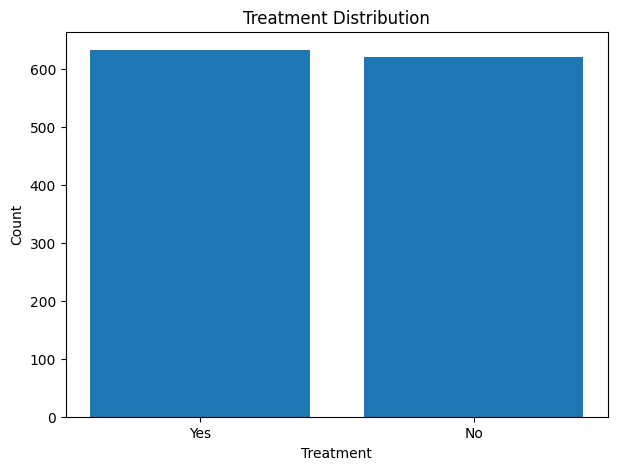

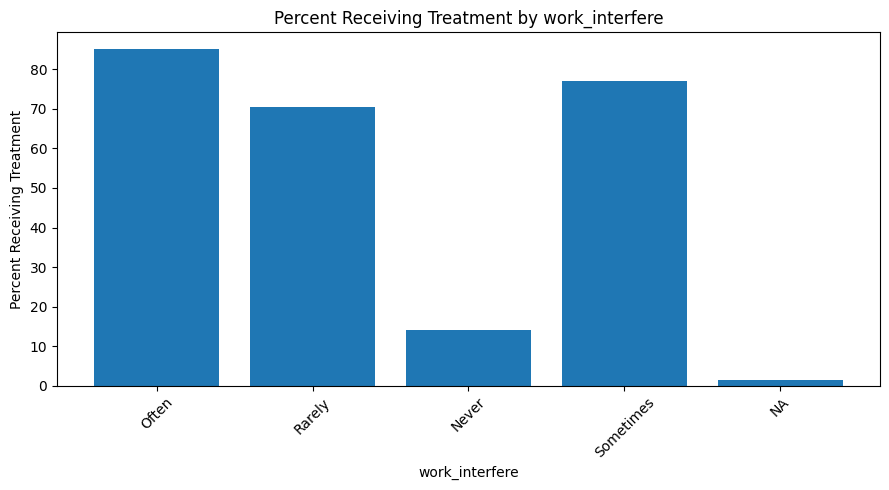

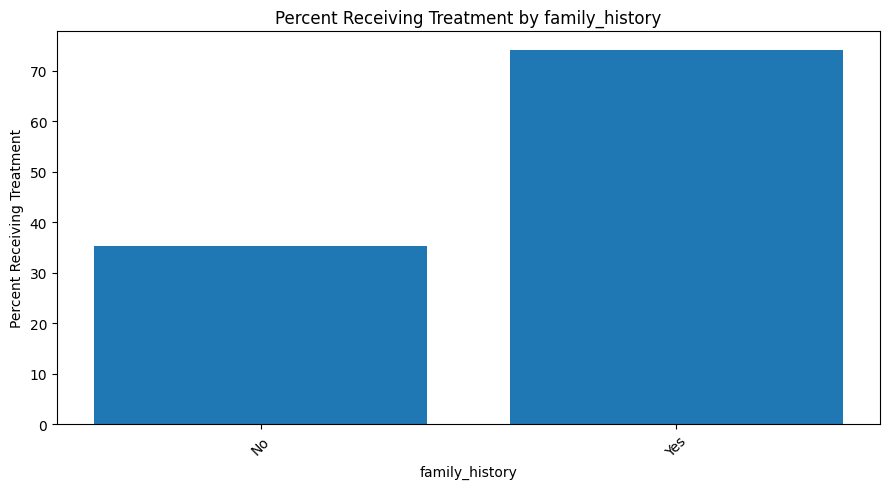

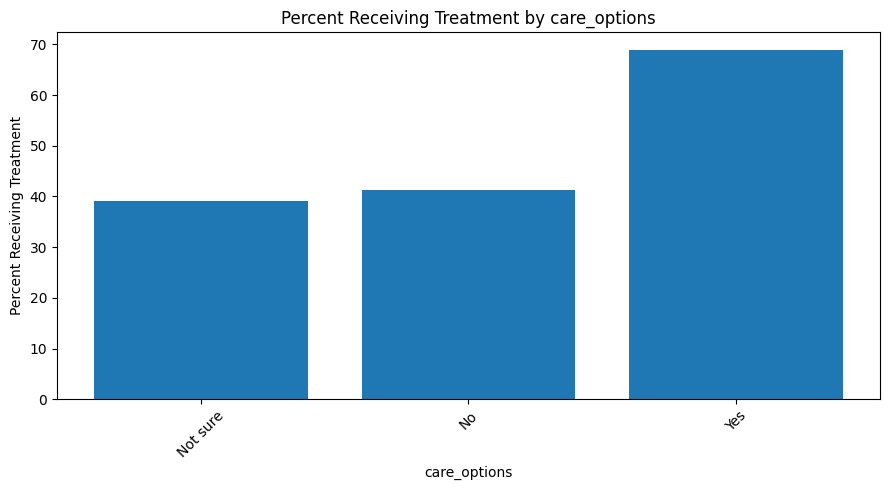

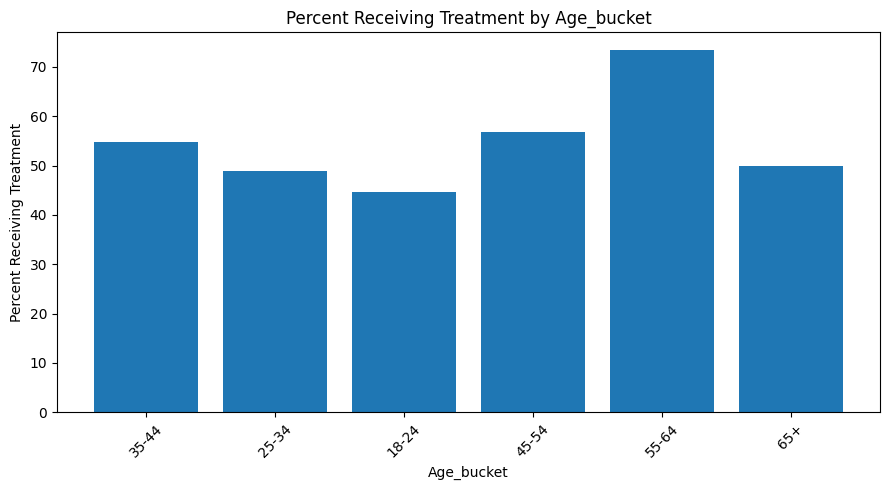

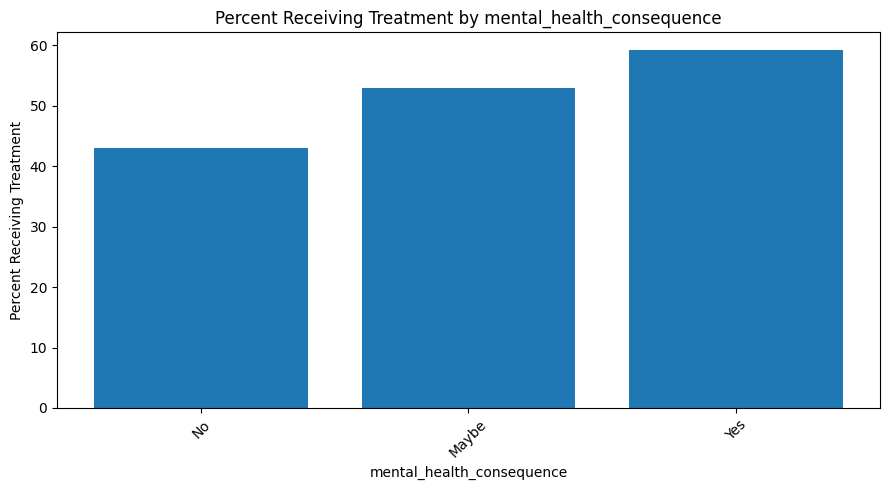

In [ ]:
## Using numpy + matplotlib
## treatment distribution
df_pd = df.to_pandas()

treatment_counts = df_pd["treatment"].value_counts()
labels = treatment_counts.index.to_numpy()
counts = treatment_counts.values

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)
plt.title("Treatment Distribution")
plt.xlabel("Treatment")
plt.ylabel("Count")
plt.show()

## treatment percentage by feature

for feature in features:
    categories = df_pd[feature].unique()

    yes_rates = []

    for category in categories:
        subset = df_pd[df_pd[feature] == category]
        yes_rate = np.mean(subset["target"]) * 100
        yes_rates.append(yes_rate)

    plt.figure(figsize=(9, 5))
    plt.bar(categories, yes_rates)
    plt.title(f"Percent Receiving Treatment by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Percent Receiving Treatment")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



#Machine Learning Algorithm

A supervised classification approach was used to predict whether an individual has sought mental health treatment.

The dataset was split into training and testing sets using an 80/20 split. The feature matrix X consisted of selected variables from the exploratory phase, while the target variable y represented treatment status.

A Random Forest classifier was implemented as the baseline model due to its ability to capture nonlinear relationships and handle mixed data types effectively.

Model performance was evaluated using standard classification metrics including:
Accuracy
Precision
Recall
F1-score


              precision    recall  f1-score   support

           0       0.86      0.74      0.80       124
           1       0.78      0.88      0.83       127

    accuracy                           0.81       251
   macro avg       0.82      0.81      0.81       251
weighted avg       0.82      0.81      0.81       251

ROC AUC: 0.8780797561595123
Hidden high-risk count: 73
   work_interfere family_history care_options Age_bucket  \
5       Sometimes            Yes     Not sure      25-34   
29      Sometimes             No           No      35-44   
31         Rarely            Yes          Yes      25-34   
48      Sometimes             No          Yes      25-34   
64      Sometimes             No           No      35-44   

   mental_health_consequence treatment  risk_score  
5                         No        No    0.718469  
29                       Yes        No    0.767432  
31                       Yes        No    0.757267  
48                        No        No    0.7

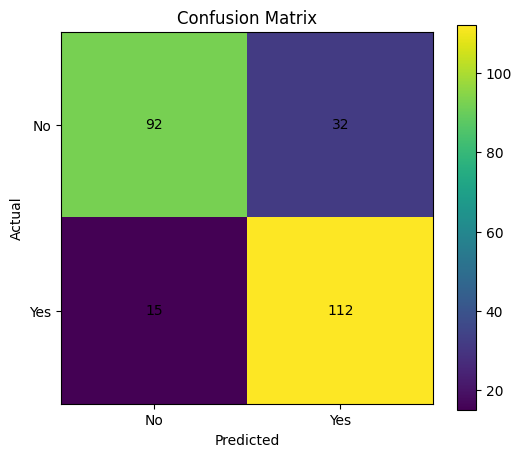

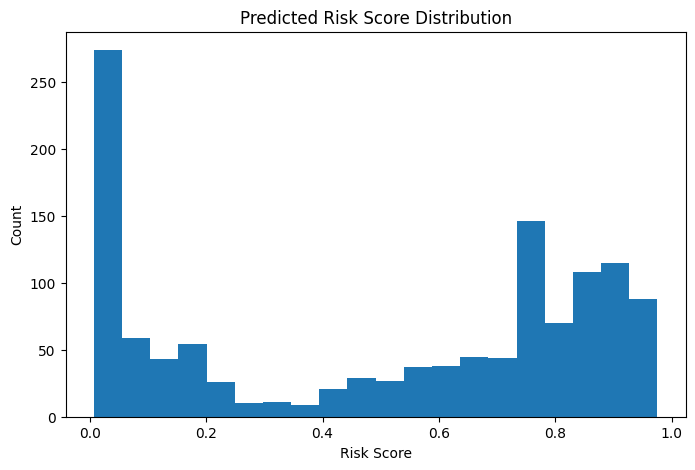

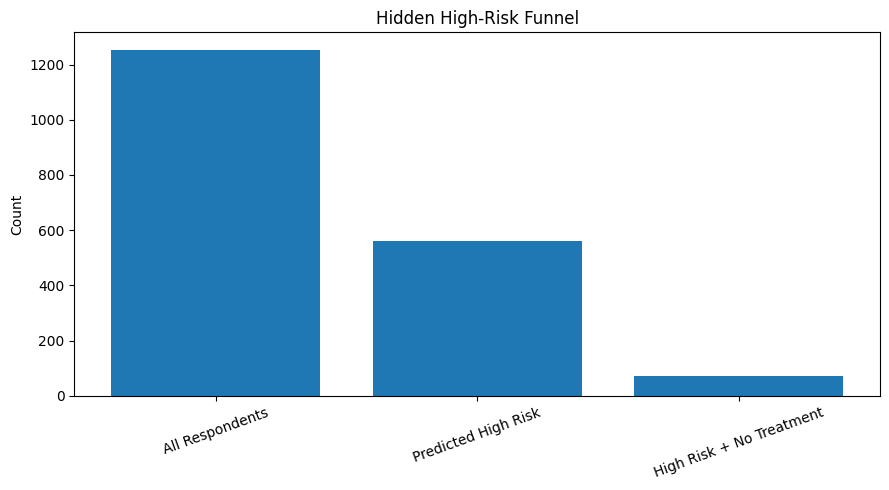

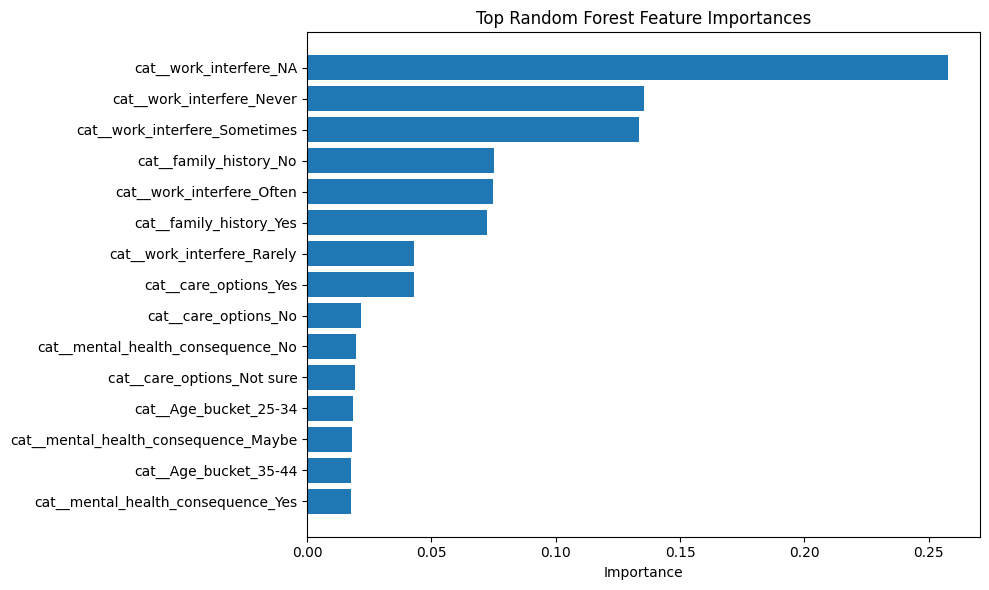

In [ ]:
#Random Forest Model Base Model
df_pd = df.to_pandas()

X = df_pd[features]
y = df_pd["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            features
        )
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

# Add predicted risk score
df_pd["risk_score"] = model.predict_proba(df_pd[features])[:, 1]

high_risk_hidden = df_pd[
    (df_pd["treatment"] == "No") &
    (df_pd["risk_score"] >= 0.70)
]

print("Hidden high-risk count:", len(high_risk_hidden))
print(high_risk_hidden[features + ["treatment", "risk_score"]].head())

##confusion matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])
plt.show()

## risk score distribution
risk_scores = df_pd["risk_score"].to_numpy()

plt.figure(figsize=(8, 5))
plt.hist(risk_scores, bins=20)
plt.title("Predicted Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

## hidden high-risk funnel

all_count = len(df_pd)
high_risk_count = np.sum(df_pd["risk_score"] >= 0.70)
hidden_high_risk_count = len(high_risk_hidden)

funnel_labels = [
    "All Respondents",
    "Predicted High Risk",
    "High Risk + No Treatment"
]

funnel_counts = np.array([
    all_count,
    high_risk_count,
    hidden_high_risk_count
])

plt.figure(figsize=(9, 5))
plt.bar(funnel_labels, funnel_counts)
plt.title("Hidden High-Risk Funnel")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## feature importance

rf_model = model.named_steps["clf"]
encoded_names = model.named_steps["prep"].get_feature_names_out()
importances = rf_model.feature_importances_

sorted_idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(encoded_names[sorted_idx], importances[sorted_idx])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#SparkML Integration

To explore scalability and performance optimization, the analysis was extended using SparkML. This involved:
Converting the dataset into a Spark DataFrame
Building a machine learning pipeline using Spark’s ML library
Applying transformations and model training in a distributed computing environment

This step demonstrates how the analysis could be scaled to larger datasets and integrated into production-level data pipelines.


Spark Data Preview:
+--------------+--------------+------------+----------+-------------------------+---------+------+
|work_interfere|family_history|care_options|Age_bucket|mental_health_consequence|treatment|target|
+--------------+--------------+------------+----------+-------------------------+---------+------+
|         Often|            No|    Not sure|     35-44|                       No|      Yes|     1|
|        Rarely|            No|          No|     35-44|                    Maybe|       No|     0|
|        Rarely|            No|          No|     25-34|                       No|       No|     0|
|         Often|           Yes|         Yes|     25-34|                      Yes|      Yes|     1|
|         Never|            No|          No|     25-34|                       No|       No|     0|
+--------------+--------------+------------+----------+-------------------------+---------+------+
only showing top 5 rows

SPARK ML MODEL COMPARISON
Model | ROC AUC | Accuracy | F1
['Spar

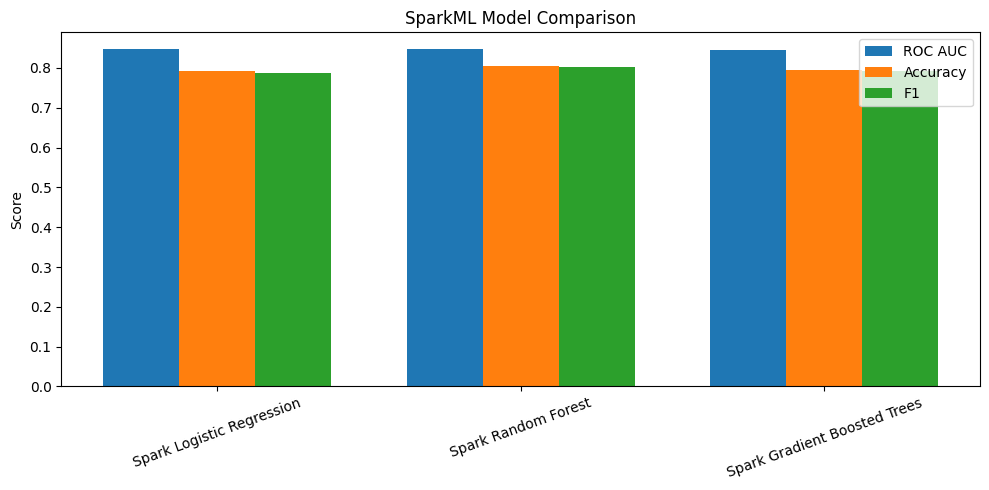

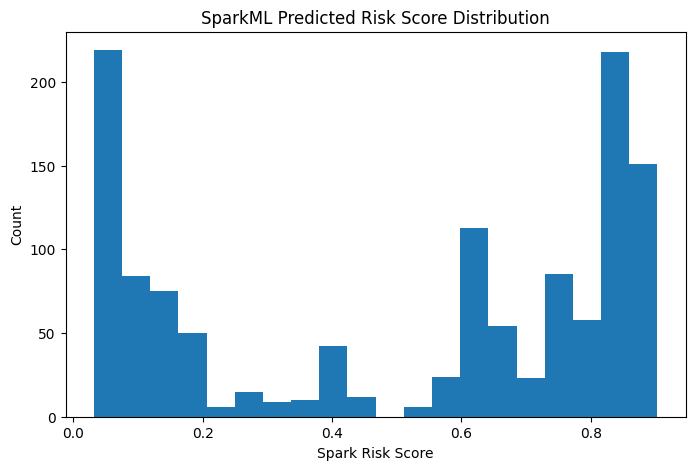

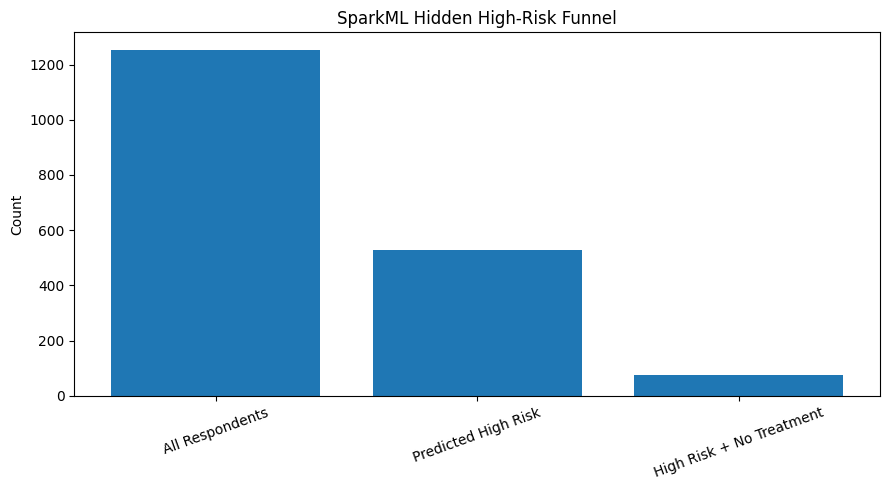

In [ ]:
##Optimized SparkML

!pip install pyspark -q

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (StringIndexer,
                                OneHotEncoder as SparkOneHotEncoder,
                                VectorAssembler)
from pyspark.ml.classification import (LogisticRegression,
                                       RandomForestClassifier as SparkRandomForestClassifier,
                                       GBTClassifier)
from pyspark.ml.evaluation import (BinaryClassificationEvaluator,
                                   MulticlassClassificationEvaluator)

import numpy as np
import matplotlib.pyplot as plt

##start Spark

spark = SparkSession.builder \
    .appName("MentalHealthSparkML") \
    .getOrCreate()

##datafram to Spark
spark_df = spark.createDataFrame(df_pd)

spark_df = spark_df.select(features + ["treatment", "target"])

## Cache data to make Spark operations faster
spark_df = spark_df.cache()
spark_df.count()

print("Spark Data Preview:")
spark_df.show(5)

##SparkML Preprocess
indexers = [
    StringIndexer(
        inputCol=feature,
        outputCol=feature + "_idx",
        handleInvalid="keep"
    )
    for feature in features
]

encoder = SparkOneHotEncoder(
    inputCols=[feature + "_idx" for feature in features],
    outputCols=[feature + "_vec" for feature in features]
)

assembler = VectorAssembler(
    inputCols=[feature + "_vec" for feature in features],
    outputCol="features"
)

##train test split

train_data, test_data = spark_df.randomSplit([0.8, 0.2], seed=42)

##evaluator

binary_evaluator = BinaryClassificationEvaluator(
    labelCol="target",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="f1"
)

##model comparison

spark_models = {
    "Spark Logistic Regression": LogisticRegression(
        labelCol="target",
        featuresCol="features",
        maxIter=50
    ),

    "Spark Random Forest": SparkRandomForestClassifier(
        labelCol="target",
        featuresCol="features",
        numTrees=100,
        maxDepth=6,
        seed=42
    ),
      "Spark Gradient Boosted Trees": GBTClassifier(
        labelCol="target",
        featuresCol="features",
        maxIter=50,
        maxDepth=4,
        seed=42
    )
}

spark_results = []
spark_trained_models = {}

for name, clf in spark_models.items():

    spark_pipeline = SparkPipeline(
        stages=indexers + [encoder, assembler, clf]
    )

    fitted_model = spark_pipeline.fit(train_data)
    predictions = fitted_model.transform(test_data)

    auc = binary_evaluator.evaluate(predictions)
    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    spark_results.append((name, auc, accuracy, f1))
    spark_trained_models[name] = fitted_model

spark_results_np = np.array(spark_results, dtype=object)

print("\nSPARK ML MODEL COMPARISON")
print("Model | ROC AUC | Accuracy | F1")

for row in spark_results_np:
    print(row)

# Smart model selection: use ROC unless they are basically tied

roc_scores = spark_results_np[:, 1].astype(float)

if max(roc_scores) - min(roc_scores) < 0.01:
    print("\nROC scores are very similar → selecting model based on F1 score")

    best_spark_model_name = spark_results_np[
        np.argmax(spark_results_np[:, 3].astype(float))
    ][0]
else:
    print("\nSelecting model based on ROC AUC")

    best_spark_model_name = spark_results_np[
        np.argmax(spark_results_np[:, 1].astype(float))
    ][0]
best_spark_model = spark_trained_models[best_spark_model_name]

print("\nBest Spark model:", best_spark_model_name)

##evaluate best model

best_spark_predictions = best_spark_model.transform(test_data)

print("\nBEST SPARK MODEL RESULTS")
print("ROC AUC:", binary_evaluator.evaluate(best_spark_predictions))
print("Accuracy:", accuracy_evaluator.evaluate(best_spark_predictions))
print("F1:", f1_evaluator.evaluate(best_spark_predictions))

##risk scoring

risk_predictions = best_spark_model.transform(spark_df)

get_risk_score = udf(lambda v: float(v[1]), DoubleType())

risk_predictions = risk_predictions.withColumn(
    "spark_risk_score",
    get_risk_score(col("probability"))
)

spark_high_risk_hidden = risk_predictions.filter(
    (col("treatment") == "No") &
    (col("spark_risk_score") >= 0.70)
)

print("\nSpark hidden high-risk respondents:")
spark_high_risk_hidden.select(
    features + ["treatment", "spark_risk_score", "prediction"]
).show(20, truncate=False)

print("Spark hidden high-risk count:", spark_high_risk_hidden.count())

##Spark Visualizations

# Model comparison chart
spark_model_names = spark_results_np[:, 0]
spark_auc_scores = spark_results_np[:, 1].astype(float)
spark_accuracy_scores = spark_results_np[:, 2].astype(float)
spark_f1_scores = spark_results_np[:, 3].astype(float)

x = np.arange(len(spark_model_names))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, spark_auc_scores, width, label="ROC AUC")
plt.bar(x, spark_accuracy_scores, width, label="Accuracy")
plt.bar(x + width, spark_f1_scores, width, label="F1")
plt.xticks(x, spark_model_names, rotation=20)
plt.ylabel("Score")
plt.title("SparkML Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Risk score histogram
spark_risk_pd = risk_predictions.select("spark_risk_score").toPandas()
spark_risk_values = spark_risk_pd["spark_risk_score"].to_numpy()

plt.figure(figsize=(8, 5))
plt.hist(spark_risk_values, bins=20)
plt.title("SparkML Predicted Risk Score Distribution")
plt.xlabel("Spark Risk Score")
plt.ylabel("Count")
plt.show()

# Hidden risk funnel
spark_all_count = spark_df.count()

spark_predicted_high_risk_count = risk_predictions.filter(
    col("spark_risk_score") >= 0.70
).count()

spark_hidden_high_risk_count = spark_high_risk_hidden.count()

spark_funnel_labels = [
    "All Respondents",
    "Predicted High Risk",
    "High Risk + No Treatment"
]

spark_funnel_counts = np.array([
    spark_all_count,
    spark_predicted_high_risk_count,
    spark_hidden_high_risk_count
])

plt.figure(figsize=(9, 5))
plt.bar(spark_funnel_labels, spark_funnel_counts)
plt.title("SparkML Hidden High-Risk Funnel")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The first model we tested was Logistic Regression, which learns linear relationships between input features and the target outcome. In this context, it demonstrated that even simple, interpretable relationships: the connection between work interference and treatment carry significant predictive power.


The second model, Random Forest, constructs an ensemble of decision trees and aggregates their predictions. This allows the model to capture nonlinear relationships and interactions between features, such as differences in behavioral patterns between responses like “Sometimes” and “Often.”


The third model, Gradient Boosted Trees, builds trees sequentially by correcting the errors of previous models. This approach is particularly effective for tabular data and is often capable of achieving high predictive accuracy by learning more complex patterns.


After comparing all three models, we found that the Random Forest model achieved slightly higher accuracy and F1 scores than the others. Although Logistic Regression had a marginally higher ROC AUC, the differences in ROC scores across models were negligible and not practically significant.

Therefore, we prioritized accuracy and F1 score for model selection.
This decision aligns with the primary objective of the project: to accurately identify individuals who are not currently receiving treatment but exhibit strong indicators of mental health risk.

In this context, metrics such as accuracy, precision, and recall are more relevant, as they directly reflect the model’s ability to correctly classify and capture high-risk individuals.


#Discussion of Value

The goal of this project was not simply to build a predictive model, but to determine whether machine learning can provide actionable value in the context of workplace mental health. The results demonstrate that survey-based models can meaningfully identify patterns associated with treatment-seeking behavior and highlight areas where organizations may have unmet employee needs. However, the true value of this work lies in how these insights can be translated into decisions and interventions.

1. Value to Organizations (Managers and Decision-Makers)

From an organizational perspective, the model provides a data-driven lens into employee well-being at scale. While companies often invest in mental health benefits, they frequently lack visibility into whether employees who need support are actually accessing it.

This project introduces a practical approach to addressing that gap:

The model can identify groups of employees who are likely to benefit from treatment but are not currently receiving it, enabling organizations to prioritize outreach and support initiatives.
The analysis reveals that factors such as work interference, family history, and awareness of care options are strongly associated with treatment-seeking. This suggests that organizations can increase engagement not only by offering benefits, but by ensuring employees understand and trust them.
Rather than relying on anecdotal feedback or low survey response interpretation, organizations can use similar models to quantitatively assess where support systems are breaking down.

Importantly, this approach shifts decision-making from reactive (responding to crises) to proactive (identifying risk patterns early).

2. Value to Employees (End Users / Consumers)

For employees, the value is indirect but significant. The insights from this model can lead to:

Improved access to mental health resources, especially for individuals who may not actively seek help due to stigma, uncertainty, or lack of awareness.
Better-designed workplace policies that reduce perceived negative consequences of discussing mental health.
Increased normalization of mental health support, particularly in environments where employees report that their condition interferes with work.

The findings suggest that many individuals who experience mental health challenges are already aware of their impact (e.g., reporting work interference), yet not all are receiving treatment. This highlights an opportunity for organizations to bridge the gap between need and action, ultimately improving employee well-being and workplace experience.

3. Value to Operational and HR Systems

At a systems level, this work demonstrates how survey data—often underutilized—can be transformed into decision-support tools.

Potential applications include:

Integrating predictive insights into HR analytics dashboards to monitor trends in employee well-being.
Informing targeted interventions such as:
improving communication about benefits,
increasing visibility of care options,
training managers to respond appropriately to mental health concerns.
Supporting resource allocation decisions by identifying which factors most strongly influence treatment uptake.

Rather than treating surveys as static reports, organizations can evolve them into continuous feedback systems augmented by machine learning.

4. Value of the Machine Learning Approach

The machine learning component adds value in several key ways:

Scalability: The model can process large volumes of survey data efficiently, making it feasible to apply across organizations of varying sizes.
Pattern discovery: It identifies complex relationships between variables that may not be immediately obvious through descriptive analysis alone.
Prioritization: By generating probability scores, the model enables organizations to rank and segment populations, rather than treating all employees uniformly.

Notably, the Logistic Regression model achieved strong recall, meaning it is effective at identifying individuals who are likely to seek treatment. In this domain, prioritizing recall is valuable because failing to identify someone who may need support is more costly than over-identifying.

5. Ethical Considerations and Responsible Use

Despite its utility, this model must be applied carefully.

The predictions should never be used for individual diagnosis or surveillance.
Employees should not be directly targeted based on model outputs.
Instead, insights should be used at an aggregate or group level to inform policy and resource allocation.

Ethically, the value of this work lies in enabling supportive environments, not in labeling or monitoring individuals. Transparency, consent, and privacy must remain central to any real-world implementation.

6. Key Takeaway

The most important insight from this project is that:

The primary value of machine learning in this domain is not prediction itself, but the ability to uncover and act on patterns of unmet need.

By combining survey data with predictive modeling, organizations can move beyond simply offering mental health resources to ensuring those resources are accessible, understood, and used by the employees who need them most.


